## DDIM inversion (initalise with MCPL pretrained)

In [ ]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from causal_modules.ddim_modules import *
size = 256

image_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [ ]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


# controlnet_path = "../logs/logs_pendulum_all/2025-05-12T12-27-57-controlnet_textcond_contrastgeneration_text_global_after/controlnet-steps-100000.safetensors"
# mcpl_embedding_path = "../logs/logs_pendulum_all/2025-05-12T12-27-57-controlnet_textcond_contrastgeneration_text_global_after/learned_embeds-steps-100000.safetensors"
controlnet_path = "../logs/logs_pendulum_all/2025-05-20T16-18-24-controlnet_image_nomcplgeneration_image/controlnet-steps-10000.safetensors"
mcpl_embedding_path = "../logs/logs_pendulum_all/2025-05-20T16-18-24-controlnet_image_nomcplgeneration_image/learned_embeds-steps-10000.safetensors"

causalnet_path = None
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
prompt = 'a image of @ and * and & and !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
training_mode generation_image
Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

In [ ]:
import os
import random
import numpy as np
from PIL import Image
import torch

def normalize_label_gaussian(label):
    # scale shape: (4, 2) -> [min, range]
    scale = np.array([[2, 42], [104, 44], [7.5, 4.5], [11, 8]])
    norm_label = np.zeros(label.shape)
    for i in range(label.shape[0]):
        norm_label[i] = (label[i] - scale[i][0]) / scale[i][1]
    return norm_label.astype(np.float32)

def dataset_load_path(
    data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/train',
    img_path=None,
    device='cuda'
):
    if img_path is None:
        # 从训练集中随机选择一个图像路径
        image_paths = [os.path.join(data_root, f) for f in os.listdir(data_root) if f.endswith('.png')]
        img_path = random.choice(image_paths)

    # 提取文件名中的标签
    filename = os.path.basename(img_path)
    label_values = list(map(int, filename[:-4].split('_')[1:]))  # 跳过开头的 'a_'

    # 归一化标签
    norm_label = normalize_label_gaussian(np.array(label_values))

    # 加载图像
    image = Image.open(img_path)

    print(f"Loaded image: {img_path}")
    print(f"Raw label: {label_values}")
    print(f"Normalized label: {norm_label}")

    return image, torch.tensor(norm_label).unsqueeze(0).to(device)


img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/pendulum_test/2/a_-8_61_5_4.png'
img, label = dataset_load_path(img_path=img_path)

Loaded image: /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/pendulum_test/2/a_-8_61_5_4.png
Raw label: [-8, 61, 5, 4]
Normalized label: [-0.23809524 -0.97727275 -0.5555556  -0.875     ]


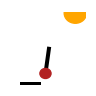

In [ ]:
img

100%|██████████| 50/50 [00:02<00:00, 16.82it/s]


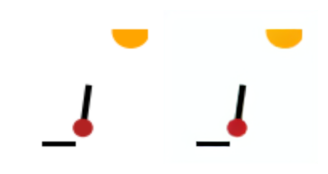

In [5]:

image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

set_guidance_scale  = 1.0
num_steps = 50
s_step = 0
final_im,inverted_latents,_ = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=1.0,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)

100%|██████████| 50/50 [00:03<00:00, 16.26it/s]


save imgs in ./intervention_variable3.png


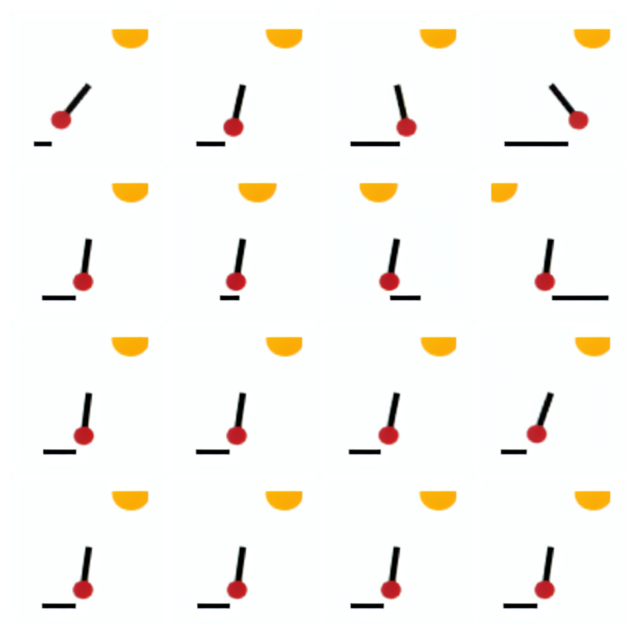

In [6]:

# Do intervention
image_lists = []
range_len = 4
inter_value = [np.linspace(-1.0, 0.8, num=range_len),
                np.linspace(-1.0, 0.9, num=range_len),
                np.linspace(-1.0, 1.0, num=range_len),
                np.linspace(-1.0, 1.0, num=range_len),
                ] 
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        s_step = 0
        interved_image,causal_cond = sample(
            pipe,
            prompt,
            start_step=s_step,
            #start_latents=None,
            start_latents=inverted_latents[-(s_step + 1)].clone(),
            guidance_scale=1.0,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label=label.clone(),
            return_PIL = True
        )
        #print(causal_cond)
        images.append(interved_image[0])
        

    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))

100%|██████████| 50/50 [00:02<00:00, 16.83it/s]


save imgs in ./intervention_variable3.png


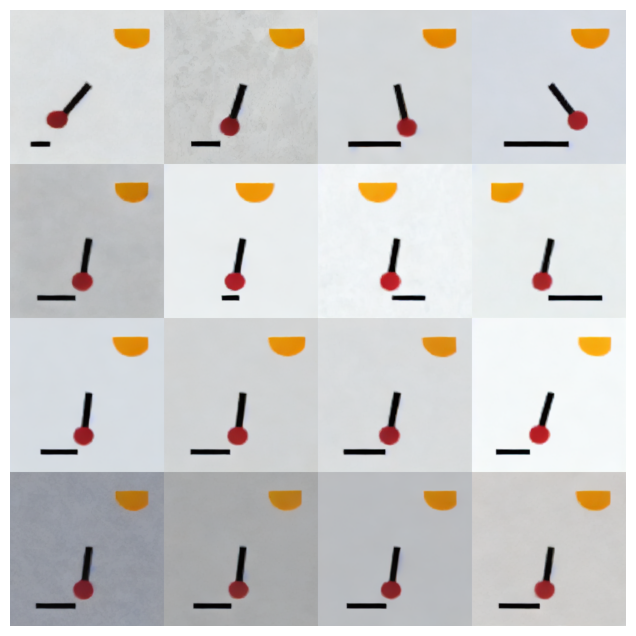

In [16]:

# Do intervention
image_lists = []
range_len = 4
inter_value = [np.linspace(-1.0, 0.8, num=range_len),
                np.linspace(-1.0, 0.9, num=range_len),
                np.linspace(-1.0, 1.0, num=range_len),
                np.linspace(-1.0, 1.0, num=range_len),
                ] 
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        s_step = 0
        interved_image,causal_cond = sample(
            pipe,
            prompt,
            start_step=s_step,
            #start_latents=None,
            start_latents=None,
            guidance_scale=1.0,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label=label.clone(),
            return_PIL = True
        )
        #print(causal_cond)
        images.append(interved_image[0])
        

    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))

# Plot Attn Maps

In [15]:
import os
prompts = [prompt]
out_base = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/outputs/attention_maps/'
exp_name = 'textcond'
if not os.path.exists(out_base):
    os.mkdir(out_base) 
out_path_base = os.path.join(out_base, exp_name)
if not os.path.exists(out_path_base):
    os.mkdir(out_path_base) 
out_path_prompt = os.path.join(out_path_base, prompts[0])
if not os.path.exists(out_path_prompt):
    os.mkdir(out_path_prompt)
out_dir = out_path_prompt
out_name = 'causalnet'+'.png'

ax shape: (1, 7)


100%|██████████| 49/49 [00:02<00:00, 17.81it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

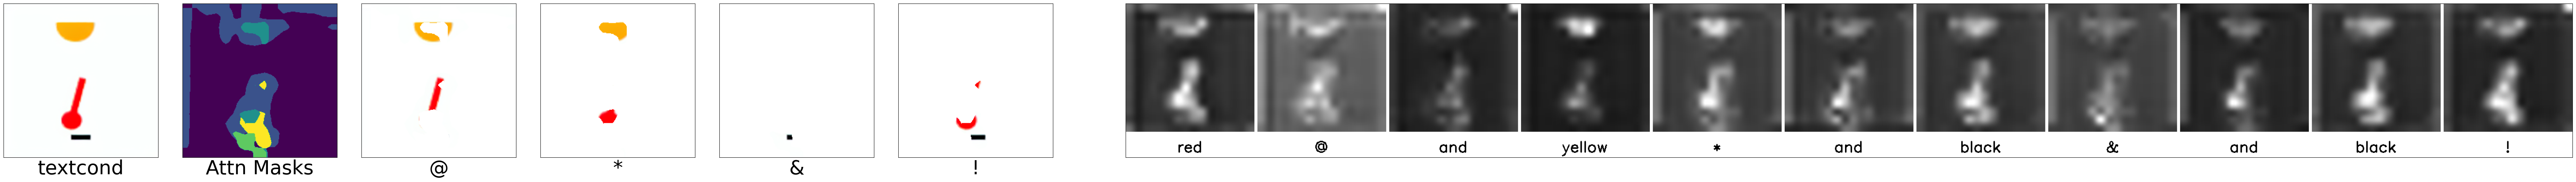

<Figure size 640x480 with 0 Axes>

In [17]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from scripts.show_attn_maps import ptp_tools,ptp_utils
import importlib
importlib.reload(ptp_tools)
importlib.reload(ptp_utils)
attn_threshold = 0.5

# pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
#     base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
# )
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
# pipe.safety_checker = None
# pipe.requires_safety_checker = False
# #pipe.load_mcpl_inversion(mcpl_embedding_path)


# # memory optimization.
# #pipe.enable_model_cpu_offload()
# pipe = pipe.to(device)

ptp_tools.plot_img_attn_mask_textcontrol(pipe, prompts,presudo_words,condition_image, \
        device, out_dir, out_name, latent=img_latent,res=16,label=label, \
        GUIDANCE_SCALE=1,attn_threshold=attn_threshold, only_sampling=False,\
        intervention_indx=None,intervention_values=None,from_where=['down','up'],mask_concepts=True, g_gpu=generator,num_steps=50,img_size=size,exp_names=[exp_name])

In [ ]:
import torch
from torch.nn import functional as F
def kl_normal(qm, qv, pm, pv):
    """
    Computes the elem-wise KL divergence between two normal distributions KL(q || p) and
    sum over the last dimension

    Args:
        qm: tensor: (batch, dim): q mean
        qv: tensor: (batch, dim): q variance
        pm: tensor: (batch, dim): p mean
        pv: tensor: (batch, dim): p variance

    Return:
        kl: tensor: (batch,): kl between each sample
    """
    element_wise = 0.5 * (torch.log(pv) - torch.log(qv) + qv / pv + (qm - pm).pow(2) / pv - 1)
    print(element_wise)
    kl = element_wise.sum(-1)

    return kl

q_m = torch.tensor([[2.0,3.0,3.0,5.0],[2.0,3.0,3.0,5.0]])
p_m  = torch.tensor([[0.0,0.0,1.0,2.5],[0.0,0.0,1.0,2.5]])
print(kl_normal(q_m,torch.ones((q_m.shape)),p_m,torch.ones((q_m.shape))))
print(0.5*F.mse_loss(q_m,p_m,reduction='sum'))

tensor([[2.0000, 4.5000, 2.0000, 3.1250],
        [2.0000, 4.5000, 2.0000, 3.1250]])
tensor([11.6250, 11.6250])
tensor(23.2500)


In [ ]:
def dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test'):
    # name like sampling_100 , sampling_500 dir
    image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
    label_list = [list(map(int,k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]
    scale = np.array([[0,44],[100,40],[6.5, 3.5],[10,5]])
    img_id = random.randint(0,len(image_paths))
    print(image_paths[img_id])
    print(label_list[img_id])

    
    label = torch.from_numpy(np.asarray(label_list[img_id]))
    array1 = np.asarray(label).astype(np.float32)
    label = torch.from_numpy(array1)
    norm_label = torch.zeros(label.shape)        
    for i in range(label.shape[0]):
        norm_label[i] = (label[i] - scale[i][0]) / scale[i][1]
    print('norm label',norm_label)
    
    return image_paths[img_id],norm_label

data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/train'
image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
label_list1 = [list(map(int, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]

# Load test labels
data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test'
image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
label_list2 = [list(map(int, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]

# Concatenate label lists
all_labels = np.array(label_list1 + label_list2)

# Compute column-wise min and max
col_min = all_labels.min(axis=0)
col_max = all_labels.max(axis=0)

print("Column-wise min values:", col_min)
print("Column-wise max values:", col_max)



Column-wise min values: [-40  60   3   2]
Column-wise max values: [ 43 147  12  19]


In [26]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

A = torch.tensor([
    [0, 1, 0, 0],
    [0, 0, 1, 1],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=torch.float32).to(device)

def get_reason_and_result_variable_indices(A):
    reason_variable_indices = []
    result_variable_indices = []

    for i in range(A.size(1)):
        col = A[:, i]

        if torch.all(col == 0):
            reason_variable_indices.append(i)
        if torch.any(col != 0):
            result_variable_indices.append(i)
    
    return reason_variable_indices, result_variable_indices

reason_v_indices, result_v_indices = get_reason_and_result_variable_indices(A)
print("Reason variable indices:", reason_v_indices)
print("Result variable indices:", result_v_indices)


Reason variable indices: [0]
Result variable indices: [1, 2, 3]
